In [1]:
%matplotlib inline
import mne 

raw = mne.io.read_raw_eeglab("../data/raw/sub-001/eeg/sub-001_task-eyesclosed_eeg.set", preload=True)
raw_filtered = raw.copy().filter(l_freq=0.5, h_freq=45.0)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 3301 samples (6.602 s)



In [2]:
#Compute variance per channel, fetch z score for each channel's variance. 
#Flag outliers 

import numpy as np 

data = raw_filtered.get_data() # shape: (n_channels, n_samples) 
channel_variances = np.var(data, axis=1) 

mean_var = np.mean(channel_variances)
std_var = np.std(channel_variances)

for ch_name, var in zip(raw_filtered.ch_names, channel_variances):
    z_score = (var - mean_var) / std_var
    print(f"{ch_name:5s} variance={var:.2e} z={z_score:+.2f}")


Fp1   variance=1.65e-09 z=+1.70
Fp2   variance=2.27e-09 z=+3.73
F3    variance=1.03e-09 z=-0.33
F4    variance=1.02e-09 z=-0.37
C3    variance=9.85e-10 z=-0.48
C4    variance=9.93e-10 z=-0.45
P3    variance=9.99e-10 z=-0.43
P4    variance=1.02e-09 z=-0.38
O1    variance=1.03e-09 z=-0.33
O2    variance=1.05e-09 z=-0.25
F7    variance=1.16e-09 z=+0.08
F8    variance=1.17e-09 z=+0.13
T3    variance=1.01e-09 z=-0.41
T4    variance=1.03e-09 z=-0.34
T5    variance=1.04e-09 z=-0.29
T6    variance=1.02e-09 z=-0.35
Fz    variance=1.01e-09 z=-0.39
Cz    variance=9.94e-10 z=-0.45
Pz    variance=1.01e-09 z=-0.40


In [ ]:
import numpy as np

sfreq = raw_filtered.info['sfreq']
window_sec = 1.0                      # check in 1 second windows
window_samples = int(window_sec * sfreq)
threshold_uv = 150e-6                 # peak2peak threshold: 150 microvolts

data = raw_filtered.get_data()
n_samples = data.shape[1]

bad_onsets = []
bad_durations = []

for start in range(0, n_samples - window_samples, window_samples):
    window = data[:, start:start + window_samples]
    ptp = window.max(axis=1) - window.min(axis=1)   # peak-to-peak per channel
    if np.any(ptp > threshold_uv):
        onset_sec = start / sfreq
        bad_onsets.append(onset_sec)
        bad_durations.append(window_sec)

print(f"Flagged {len(bad_onsets)} bad windows out of {n_samples // window_samples} total")
print("Onsets (sec):", bad_onsets)

Flagged 165 bad windows out of 599 total
Onsets (sec): [0.0, 1.0, 2.0, 5.0, 8.0, 12.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 42.0, 46.0, 60.0, 61.0, 63.0, 70.0, 71.0, 73.0, 79.0, 81.0, 84.0, 85.0, 97.0, 98.0, 102.0, 103.0, 117.0, 120.0, 121.0, 122.0, 129.0, 135.0, 149.0, 152.0, 155.0, 160.0, 161.0, 162.0, 164.0, 165.0, 166.0, 167.0, 171.0, 175.0, 176.0, 178.0, 180.0, 181.0, 182.0, 190.0, 192.0, 194.0, 195.0, 196.0, 198.0, 202.0, 203.0, 210.0, 211.0, 214.0, 215.0, 218.0, 219.0, 238.0, 241.0, 242.0, 246.0, 248.0, 249.0, 254.0, 255.0, 256.0, 265.0, 266.0, 269.0, 270.0, 279.0, 282.0, 287.0, 298.0, 299.0, 300.0, 301.0, 306.0, 318.0, 319.0, 324.0, 328.0, 329.0, 330.0, 335.0, 339.0, 345.0, 351.0, 358.0, 364.0, 365.0, 366.0, 372.0, 373.0, 374.0, 377.0, 383.0, 384.0, 389.0, 393.0, 408.0, 419.0, 449.0, 450.0, 451.0, 453.0, 454.0, 456.0, 463.0, 466.0, 467.0, 469.0, 473.0, 479.0, 482.0, 486.0, 487.0, 491.0, 492.0, 497.0, 502.0, 503.0, 504.0, 510.0, 512

In [6]:
all_ptps = []
for start in range(0, n_samples - window_samples, window_samples):
    window = data[:, start:start + window_samples]
    ptp = window.max(axis=1) - window.min(axis=1)
    all_ptps.append(ptp.max())  # worst channel in this window

all_ptps = np.array(all_ptps)
print("Percentiles (µV):")
for p in [50, 75, 90, 95, 97, 99]:
    print(f"  {p}th percentile: {np.percentile(all_ptps, p) * 1e6:.1f} µV")

Percentiles (µV):
  50th percentile: 129.2 µV
  75th percentile: 152.2 µV
  90th percentile: 178.0 µV
  95th percentile: 197.5 µV
  97th percentile: 234.7 µV
  99th percentile: 322.4 µV


In [7]:
threshold_uv = np.percentile(all_ptps, 95)
print(f"Using threshold: {threshold_uv * 1e6:.1f} µV")

bad_onsets = []
bad_durations = []

for start in range(0, n_samples - window_samples, window_samples):
    window = data[:, start:start + window_samples]
    ptp = window.max(axis=1) - window.min(axis=1)
    if np.any(ptp > threshold_uv):
        onset_sec = start / sfreq
        bad_onsets.append(onset_sec)
        bad_durations.append(window_sec)

print(f"Flagged {len(bad_onsets)} bad windows out of {n_samples // window_samples} total")
print(f"That's {100 * len(bad_onsets) / (n_samples // window_samples):.1f}% of the recording")

Using threshold: 197.5 µV
Flagged 30 bad windows out of 599 total
That's 5.0% of the recording


In [8]:
print(bad_onsets)

[0.0, 1.0, 20.0, 22.0, 24.0, 25.0, 26.0, 27.0, 33.0, 71.0, 98.0, 161.0, 167.0, 195.0, 210.0, 330.0, 365.0, 372.0, 377.0, 450.0, 451.0, 453.0, 487.0, 529.0, 530.0, 531.0, 532.0, 533.0, 534.0, 590.0]


In [9]:
onset_array = np.array(bad_onsets)
duration_array = np.array(bad_durations)
descriptions = ['BAD_amplitude'] * len(bad_onsets)

annotations = mne.Annotations(onset=onset_array, duration=duration_array, description=descriptions)
raw_filtered.set_annotations(annotations)

print(raw_filtered.annotations)

<Annotations | 30 segments: BAD_amplitude (30)>


Using matplotlib as 2D backend.


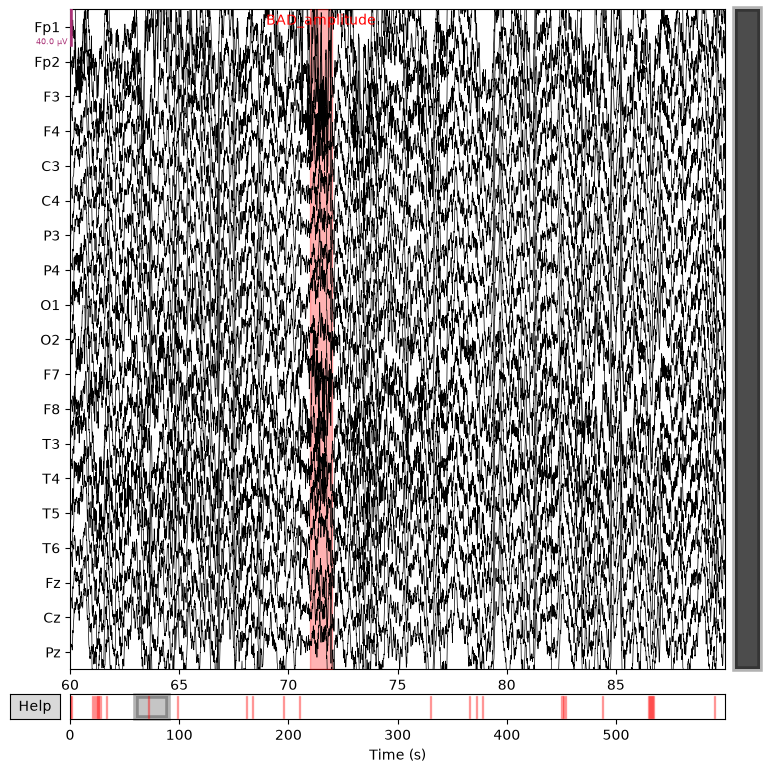

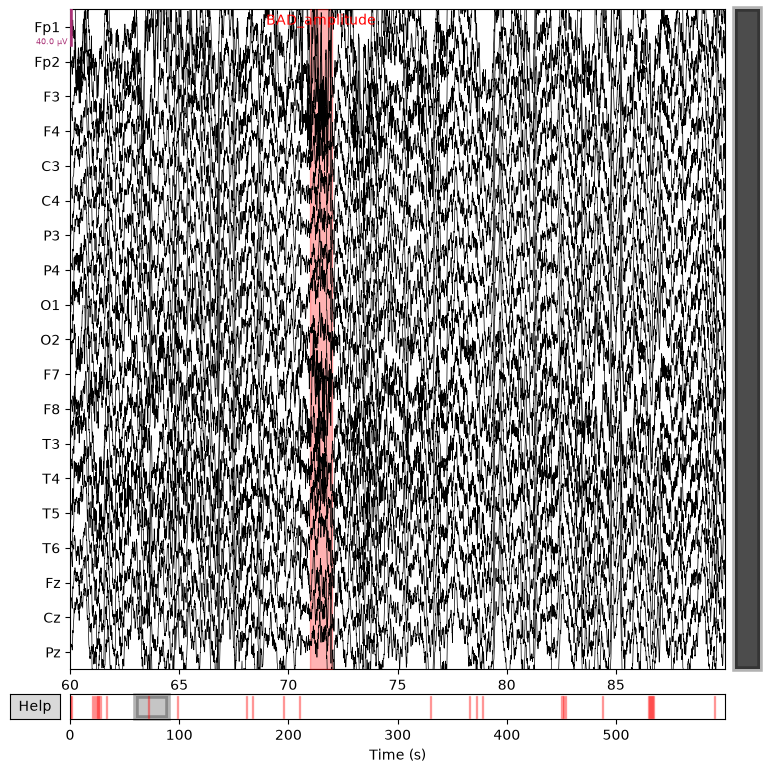

In [10]:
raw_filtered.plot(n_channels=19, duration=30, start=60, scalings=dict(eeg=20e-6))

In [11]:
raw_for_ica = raw_filtered.copy().filter(l_freq=1.0, h_freq=None)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1651 samples (3.302 s)



In [12]:
from mne.preprocessing import ICA

ica = ICA(n_components=15, random_state=42, max_iter="auto")
ica.fit(raw_for_ica)

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Omitting 15000 of 299900 (5.00%) samples, retaining 284900 (95.00%) samples.
Selecting by number: 15 components
Fitting ICA took 6.4s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,25 iterations on raw data (284900 samples)
ICA components,15
Available PCA components,19
Channel types,eeg
ICA components marked for exclusion,—


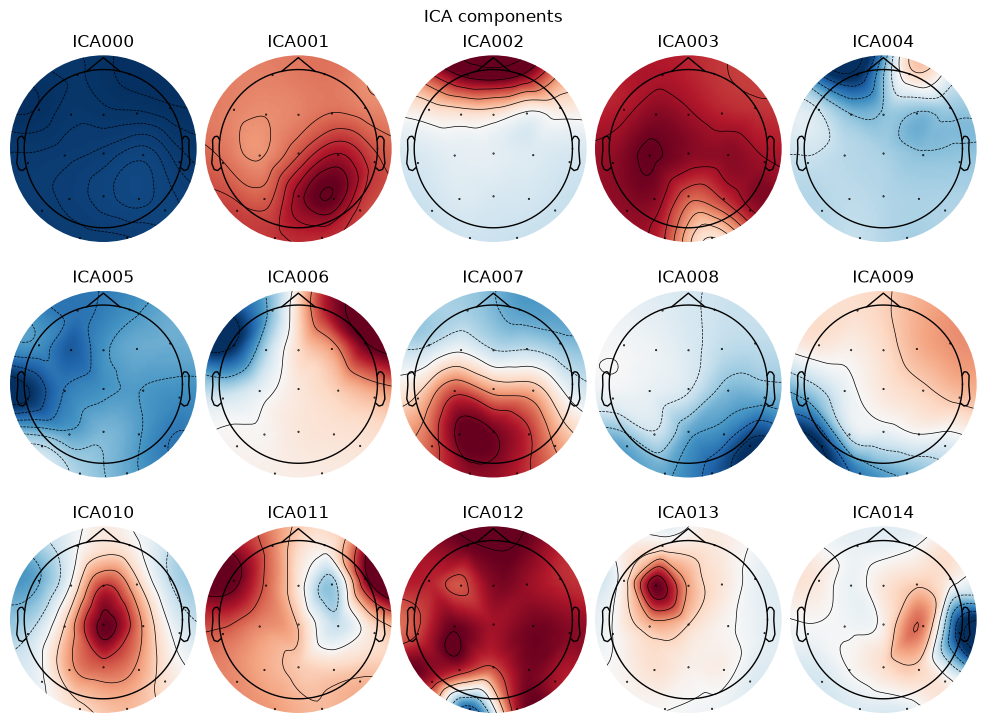

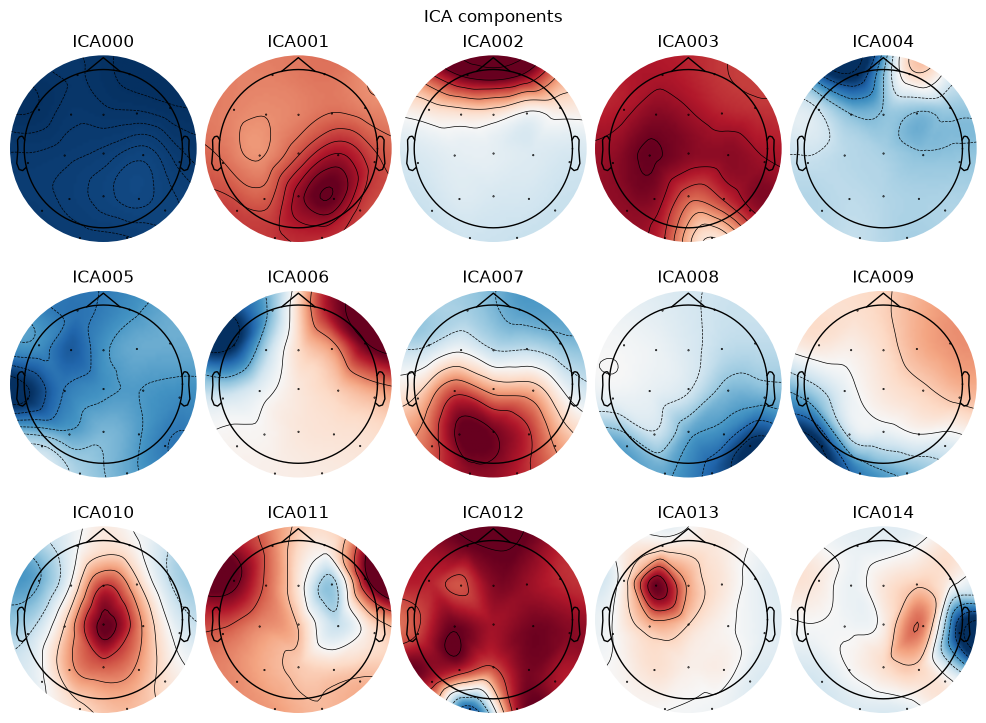

In [13]:
ica.plot_components()

Creating RawArray with float64 data, n_channels=15, n_times=299900
    Range : 0 ... 299899 =      0.000 ...   599.798 secs
Ready.


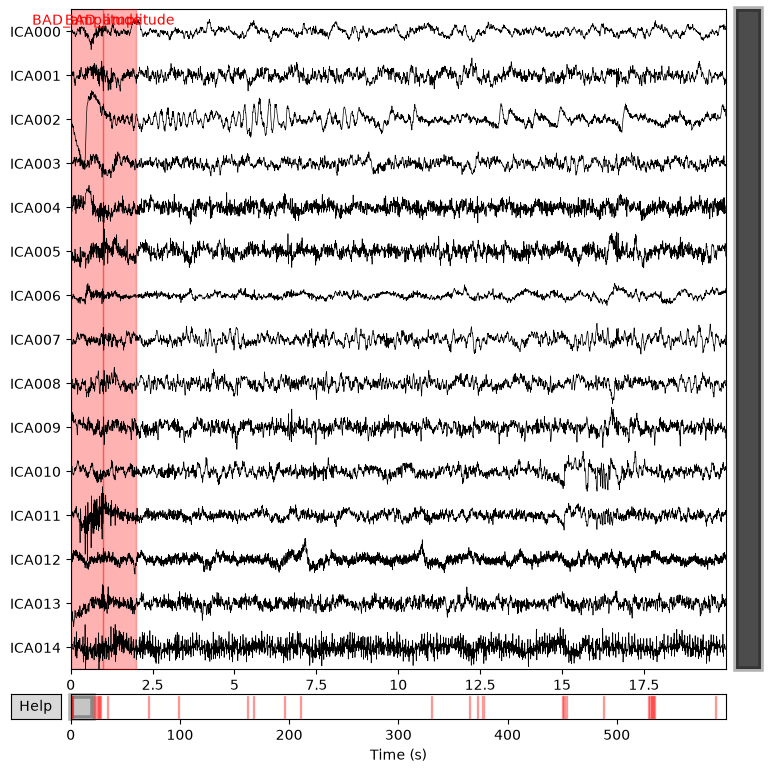

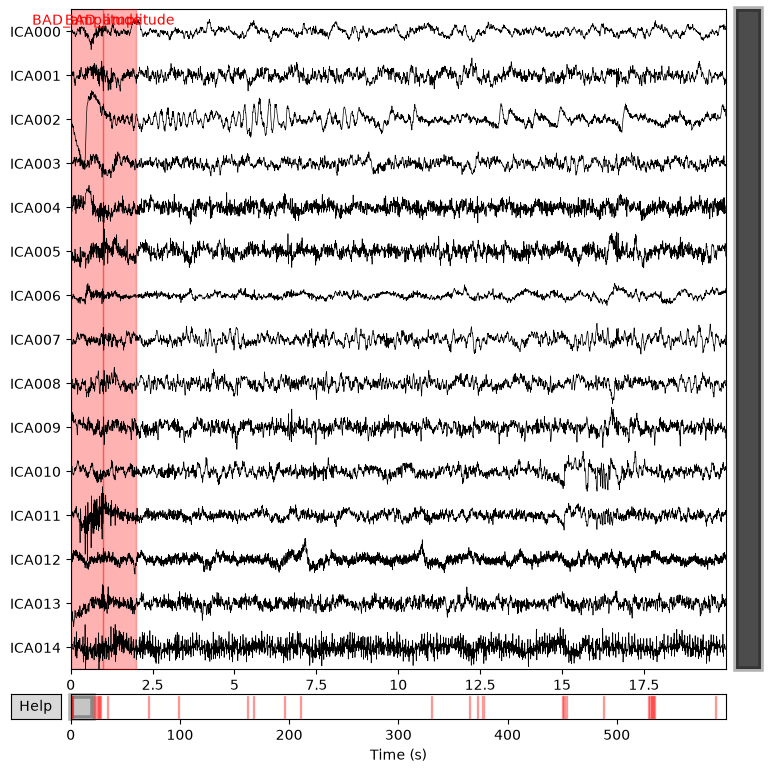

In [14]:
ica.plot_sources(raw_for_ica)

In [15]:
eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica, ch_name='Fp1')
print("Suspected artifact components:", eog_indices)
print("Correlation scores:", eog_scores)

Using EOG channel: Fp1
Omitting 15000 of 299900 (5.00%) samples, retaining 284900 (95.00%) samples.
Omitting 15000 of 299900 (5.00%) samples, retaining 284900 (95.00%) samples.
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidt

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
275 matching events found
No baseline correction applied
0 projection items activated


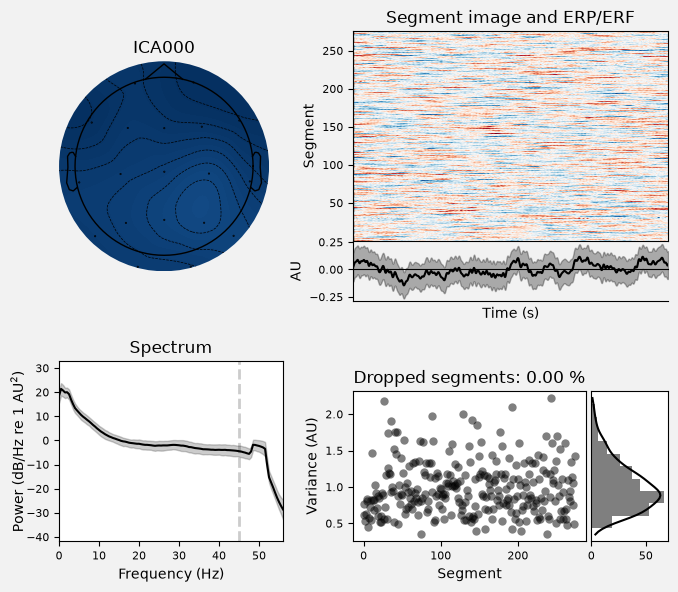

[<Figure size 700x600 with 6 Axes>]

In [16]:
ica.plot_properties(raw_for_ica, picks=[0])

In [17]:
ica.exclude = [0]
raw_clean = raw_filtered.copy()
ica.apply(raw_clean)

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 19 PCA components


<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

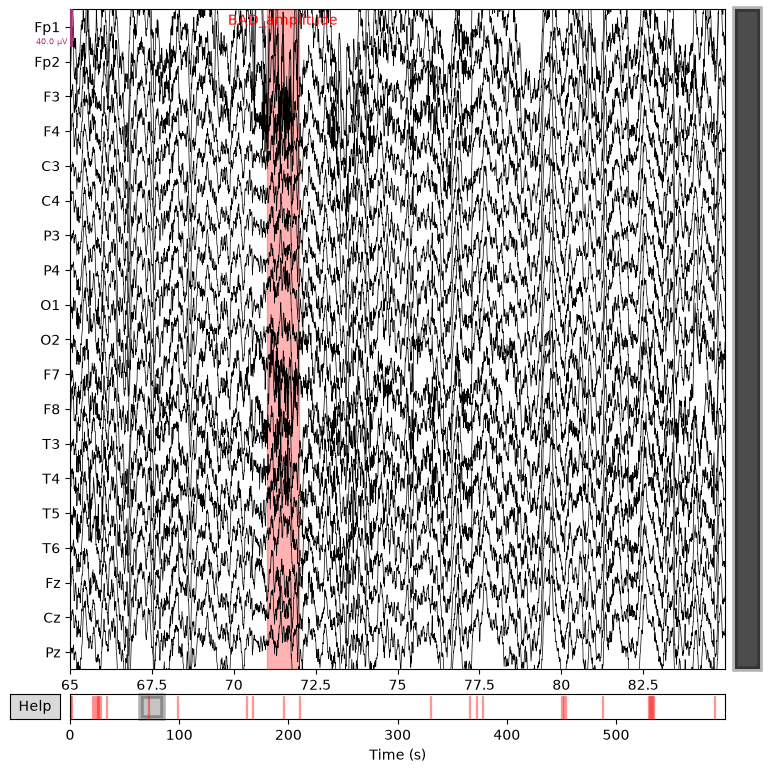

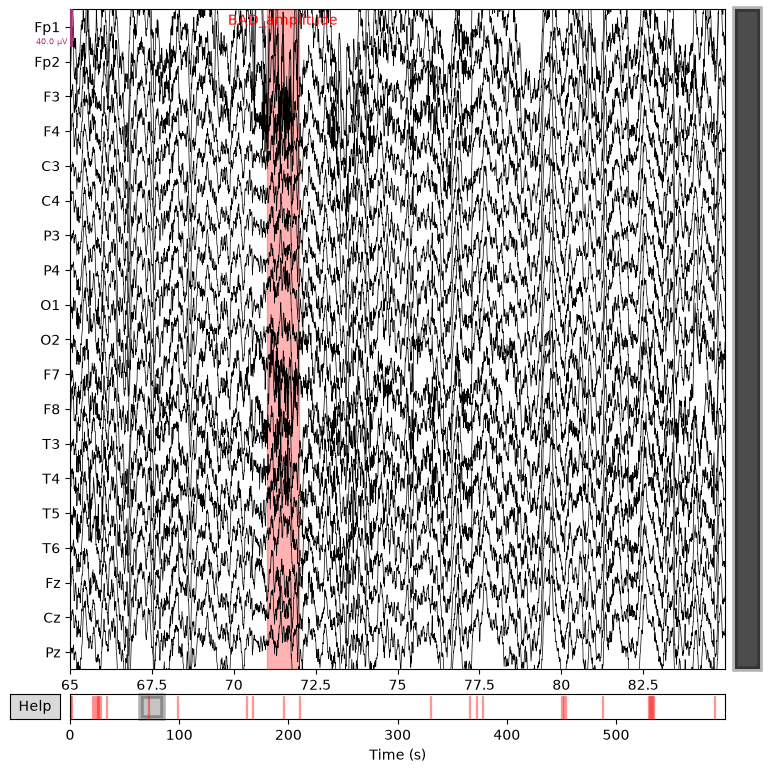

In [19]:
raw_filtered.plot(n_channels=19, duration=20, start=65, scalings=dict(eeg=20e-6))

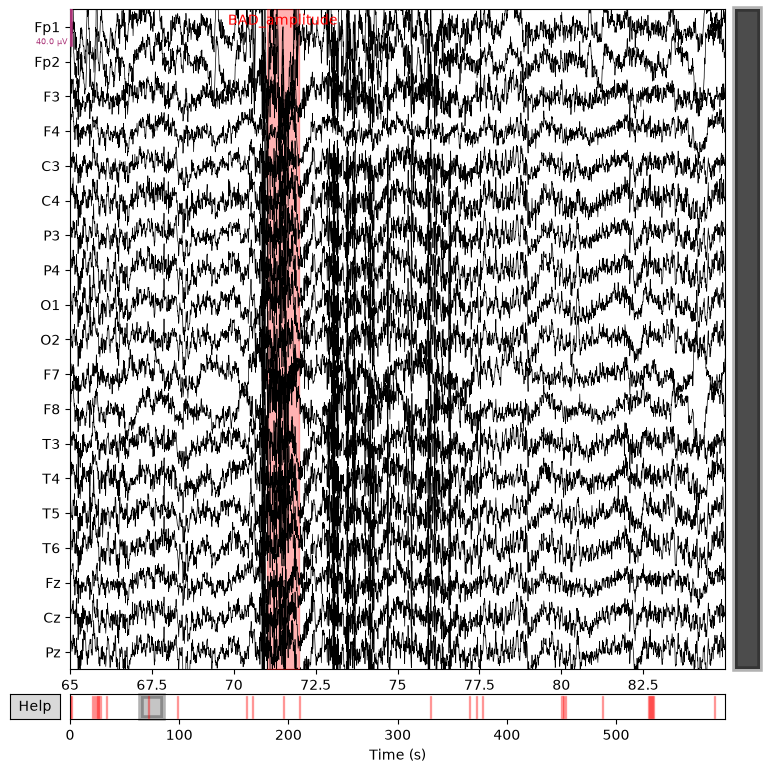

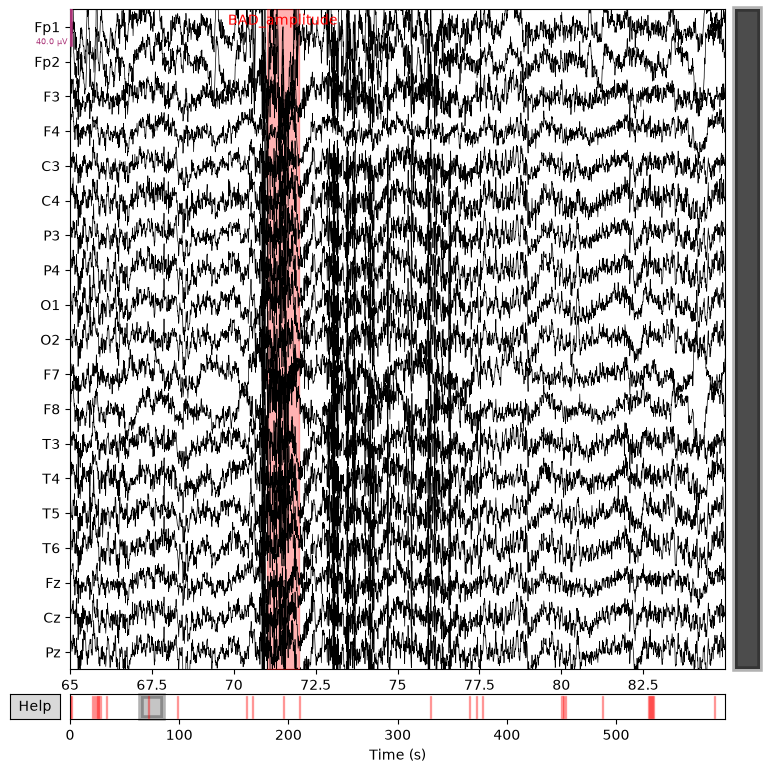

In [20]:
raw_clean.plot(n_channels=19, duration=20, start=65, scalings=dict(eeg=20e-6))

In [21]:
raw_reref = raw_clean.copy().set_eeg_reference('average')

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


In [22]:
epochs = mne.make_fixed_length_epochs(
    raw_reref, 
    duration=4.0,
    overlap=0.0,
    preload=True,
    reject_by_annotation=True
)
print(epochs)

Not setting metadata
149 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 149 events and 2000 original time points ...
20 bad epochs dropped
<Epochs | 129 events (all good), 0 – 3.998 s (baseline off), ~37.4 MiB, data loaded,
 '1': 129>


In [23]:
epochs.save("../data/processed/sub-001_epo.fif", overwrite=True)

[PosixPath('/Users/aidanseidman/Desktop/eeg-dementia-classifier/notebooks/../data/processed/sub-001_epo.fif')]